# Linear Regression for Machine Learning 📈


Remember the machine learning workflow?
We briefly discussed it in [lecture 1](./week01-lecture.ipynb)

**Machine Learning Workflow**

<img src="images/lec01_MLprocess.png" width="400">

## Open a New Jupyter Notebook 🙌

By now you should know the sequence:

- Open Anaconda Prompt (or Terminal on Mac)
- Activate the environment $\rightarrow$ conda activate mle5217
- Start jupyter notebook $\rightarrow$ start jupyter notebook

Download and save your dataset into the same folder as your notebook.

To run a machine learning task, the earlier dataset seems a bit too small, so let's use another dataset which can be **[downloaded here](data/lec03-stress_strain.csv)**

OK, Let's start..

## ❓Problem Definition

Our dataset has two columns `stress` and `strain`.
This is a simple dataset with no additional columns or data to worry about. We will assume that all data are valid & unique measurements, with some instrumental uncertainties in their measurements.

Which is the independent variable and which is the dependent variable?
Usually, in a stress-strain measurement we apply a stress to the sample and measure the strain. So, the strain changes with respect to stress.

independent variable $(x) \rightarrow$  stress

dependent variable $(y) \rightarrow$  strain

## Data Preprocessing

This is usually the Big One!

In classical machine learning, this is where we tend to spend most of our time and effort. *Data preprocessing* is a broad term for all the steps needed to turn raw data into a clean, tidy format that a model can actually work with.

```{admonition} Analogy: making a pot of soup 🍲
:class: tip
Think about making soup. In principle it's simple - toss some vegetables, meat, and broth into a pot and let it all simmer.

But getting to *that* point takes a fair bit of work. The vegetables need washing, rotten ones need throwing out, some need peeling, a few need bits trimmed away, and everything has to be chopped into pieces before it goes in the pot. That prep work is exactly what preprocessing does for your data.
```

To keep this first exercise gentle, the dataset we're using is already mostly clean enough to work with, so there's very little prep to do here (enjoy it while it lasts!).

But we will explore it a bit and ensure everything is fine.

Once the data is clean, there's one more step before we start modelling: splitting it into two sets.

### Train–Test Split ⚡

This is a phrase you'll hear again and again - in this course, and right across machine learning, deep learning, and AI in general.

The idea is straightforward. We divide our data into a **training set** and a **test set**. The model learns the hardness-to-strength relationship *only* from the training set, and we deliberately keep the test set aside, unseen, so that later we can check how the model performs on data it has never encountered. A common choice is roughly 80% of the data for training and 20% for testing, though the exact proportion can vary from project to project.

```{admonition} Analogy: Teaching a class in school 👨‍🏫
:class: tip
Imagine you have to teach multiplication to a class of Year 5 students. First, you let them practise - you give them 50 problems to work through, so they learn the technique.

At the end of the month, you want to check how well they have learnt it. So you set a test of 10 questions.

Now, would you use some of the exact same problems they practised earlier?

Probably not. A student might simply have memorised the answers without ever understanding the technique. The test would look good, but it would tell you nothing.

So you give them new numbers instead. Only then can you see who truly understands multiplication.

This is exactly the idea behind the train–test split in machine learning.

We divide our data into two parts: a training set and a test set. The model learns from the training set only - we keep the test set hidden until training is finished. Then we show the model the test data and see how well it performs. Because it has never seen those examples before, a good score means it has learnt the underlying pattern, not just memorised the answers.
```

## Model Selection & Training

Our task is to map each Vickers hardness value to a tensile strength value. Both are continuous numbers, which makes this a **regression** problem - and a linear one at that, since we're expecting a straight-line relationship.

That makes linear regression a natural choice of model, and it's exactly what we'll build today.

## Model Evaluation

Once training is complete, we bring out the test set to see how well the model actually performs.

```{note}
Our model is only ever trained on the training data - it has **never** seen the test data before.
```

This is the real test of whether the model has captured the genuine relationship between stress and strain. If it has, it should still make fairly accurate predictions on those unseen test specimens. We'll do this by measuring how close its predictions land to the true values.

## Model Tuning & Improvement

Finally, once we know how our model performs, we can start thinking about ways to make it better. For this first exercise we'll keep things simple and save these techniques for a later session - something to look forward to!

 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [26]:
#Set the path to where the dataset is
data = pd.read_csv("data/lec03-stress_strain.csv")

In [3]:
data.head()

,strain,stress
0,0.05905,372.4
1,0.05914,399.8
2,0.05923,400.7
3,0.05930,400.6
4,0.05937,399.5


In [4]:
data1 = data.copy()
len(data1)

447

In [5]:
data1.describe()

,strain,stress
count,447.000000,446.000000
mean,0.075934,429.893946
std,0.009711,17.933119
min,0.059050,372.400000
25%,0.067595,415.000000
50%,0.075950,429.700000
75%,0.084325,444.300000
max,0.092630,480.900000


In [6]:
data1.dropna(axis=0,how='any')

,strain,stress
0,0.05905,372.4
1,0.05914,399.8
2,0.05923,400.7
3,0.05930,400.6
4,0.05937,399.5
...,...,...
442,0.09234,461.4
443,0.09241,463.6
444,0.09249,462.1
445,0.09256,480.9


In [7]:
len(data1)   # Check this, why?

447

In [8]:
data1 = data1.dropna(how='any',axis=0)
len(data1)

446

In [9]:
data1.describe()  #Check if both strain and stress are the same

,strain,stress
count,446.000000,446.000000
mean,0.075944,429.893946
std,0.009720,17.933119
min,0.059050,372.400000
25%,0.067577,415.000000
50%,0.075995,429.700000
75%,0.084343,444.300000
max,0.092630,480.900000


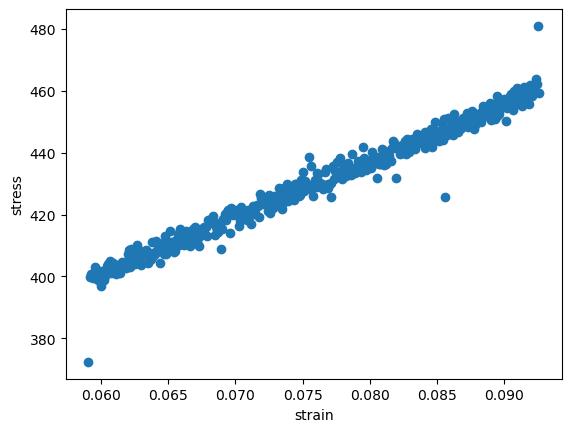

In [10]:
#Let's visualize the data
plt.scatter(x=data1['strain'],y=data1['stress'])
plt.xlabel("strain")
plt.ylabel('stress')
plt.show()

Notice that the two scales x and y values are on different magnitude scales x varies ~0-0.1 whereas y varies ~400-460 It is a good practice to normalize these data, but we'll ignore it for now and focus on our main interest - carrying out the ML process. We will get to the normalization and standardization of data later.

Let's separate the X and y variable columns into separate dataframes. - why? Because y is the target variable - what we are trying to predict. In the testing dataset, we should only feed in the X data and predict the y, before checking with the actual y data. So we need X and y separated.

In [11]:
X = data1[["strain"]]
y = data1[["stress"]]

print(f'shape of x is : {X.shape}')
print(f'shape of y is : {y.shape}')

shape of x is : (446, 1)
shape of y is : (446, 1)


In [12]:
type(X)

pandas.core.frame.DataFrame

Splitting data=============

In ML, the next step is to split the data into training, validation and testing datasets. The percentages of splitting can be determined according to the nature of the dataset. But 80/20 or 70/20/10 is a common split ratio. Since this is our first example, just to keep things simple, let's just split into train and test sets. You will see that the method can be later extended to a validation set.

train dataset - data used to train the model validation dataset - data held back to fine-tune the model test dataset - data held back to do a final test and metrics on the model

In [13]:
#Now we will split the data into train and test sets
#train to test ratio : 0.8:0.2

X_train, X_test, y_train,y_test = train_test_split(X,y,train_size=0.8)      #Array / list unpacking
print(X_train)


      strain
45   0.06253
412  0.09011
313  0.08271
293  0.08117
277  0.08001
..       ...
316  0.08294
314  0.08279
138  0.06962
4    0.05937
20   0.06061

[356 rows x 1 columns]


In [14]:
#Everytime you run the code, you get a different (random) split; but if you want to build a reproducible model,
#you need to hold a single split while you work through & complete the model
#Random Split control

X_train, X_test, y_train,y_test = train_test_split(X,y,train_size=0.8,random_state=12)      #Array / list unpacking
print(X_train)

      strain
42   0.06228
248  0.07783
235  0.07686
69   0.06436
150  0.07051
..       ...
242  0.07739
254  0.07829
391  0.08855
155  0.07089
332  0.08414

[356 rows x 1 columns]


If you had multiple independent variables (x), then this is where you featurize them / more on that later

In [15]:
model = LinearRegression()
result = model.fit(X_train,y_train)

In [16]:
#Let's see how the predicted model fits the training data
y_train_predict = model.predict(X_train)
#print(y_predict)

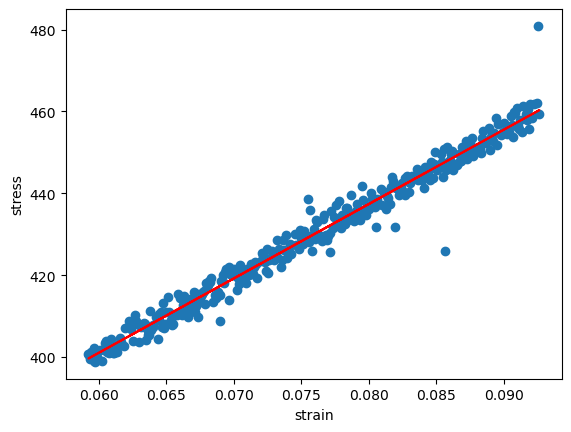

In [17]:
plt.scatter(X_train,y_train)
plt.xlabel("strain")
plt.ylabel("stress")
plt.plot(X_train,y_train_predict,color='red')
plt.show()

In [18]:
#Let's check the score (r2 value) for the training data
r2=model.score(X_train,y_train)
print(r2)

0.9761494901203318


score() doesn't always work for all models, it's a quick and easy tool. But a more specific one is r2_score

Key Differences:

score() is a general method that is model-specific and returns a default evaluation metric (R² for regression, accuracy for classification).
r2_score() is specifically designed for calculating the R² score for regression models.

In [19]:
from sklearn.metrics import r2_score

In [20]:
#input to r2_score function needs to be array-like

#type(y_test)
type(y_train_predict)

numpy.ndarray

So y_predict is ok, but y_test is a pandas dataframe that needs to be converted to a numpy array before we use it in the fucntion

In [21]:
y_train_arr = y_train.to_numpy()

In [22]:
type(y_train_arr)

numpy.ndarray

In [23]:
r_squared=r2_score(y_train_arr,y_train_predict)
print(r_squared)

0.9761494901203318


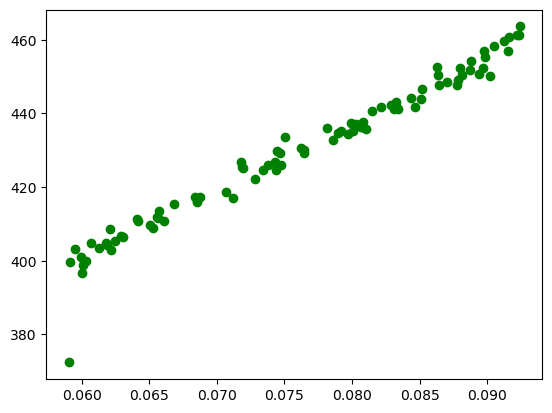

In [24]:
#If you only want to see the test data ------------------------------
plt.scatter(X_test,y_test,color="green")
plt.show()

In [25]:
r2_test=model.score(X_test,y_test)
print(r2_test)

0.9663195938313538


# What does $r^2$ mean?

How good is our fit?

We have drawn a straight line through our data. But how do we know if it is a good line? We need a number.

Start with a simpler question: what if we had no model at all? The best we could do is guess the average stress for every sample. That is our baseline - the worst a sensible model should ever do.

R² compares our model against that baseline. It asks: how much of the variation in the data has our line managed to explain?

$R^2 = 1-\frac{\sum(y_i-\hat{y}_i)^2}{\sum(y_i-\bar{y}_i)^2}$

The top of the fraction is the error our model still makes. The bottom is the error the baseline makes. If our model's errors are small compared to the baseline, the fraction is small and R² is close to 1.

R² = 1 - the line passes through every point exactly.

R² = 0.95 - our model explains 95% of the variation. Good.

R² = 0 - our model is no better than just guessing the average.

R² < 0 - our model is worse than guessing the average. This is possible, and it usually means something has gone wrong.

# ⚠️ 
A high R² does not always mean a good model. A curved relationship can still give a high R² when fitted with a straight line, and adding more features will always push R² up, even if those features are meaningless. Always look at your plot as well as your number.

:class: tip
**Coefficient of determination** - the formal name for R².
**Explained variance** - the part of the spread in the data that the model accounts for.
**Residual sum of squares** - the top of the fraction; the error left over.
**Total sum of squares** - the bottom; the error of the baseline model.

# Correlation Does not Imply Causation

*Causation $\rightarrow$ One causes the other*

Just because two (or more) variables are correlated, doesn't mean that they have a causal relationship.

<img src="images/lec03-correlation_causation_cats.jpg" width="500">


This is a real concern in medical statistics.
For example consider the statement: "Smoking causes lung cancer"

ALthough the data between lung cancer occurences and smoking prevalence is very high, we don't have a direct scientific pathway to explain *how a specific ingredient (or a mix of ingredients) is absorbed by the inner walls of alveoli ...which in turn causes genetic mutations ... turns into cancerous growth*.
Instead all we have is data which shows a correlation. Which makes us very suspicious of a connection, but at the same time there could be other (secondary) connections which our data doesn't show. 

So, medical professionals now tend to say "Smoking is a **risk factor** for lung cancer", or "Excessive sugar consumption is a risk factor for diabetes" etc.


# Practice Problem

You can download a synthetic [dataset for Vickers hardness](data/lec03-regression_ML.csv) and try out building a regression model.


## ❓Problem Definition 	

Our dataset has three columns: `specimen_id`, `vickers_hardness_hv`, and `tensile_strength_mpa`.

- `specimen_id` is a unique label (like `S001`, `S002`, …) that lets us tell one specimen apart from another. It's a categorical identifier - essentially a name tag - so we won't feed it into the model as a feature.
- `vickers_hardness_hv` is the Vickers hardness measured for each steel specimen.
- `tensile_strength_mpa` is that specimen's ultimate tensile strength, in megapascals.

For carbon and low-alloy steels, ultimate tensile strength tends to scale roughly linearly with Vickers hardness - put simply, harder steels are generally stronger. We've got two goals today: first, to check whether that relationship holds in *our* dataset, and second, to build a simple model that can predict a specimen's tensile strength from its hardness alone.

In other words, our independent variable $x$ is `vickers_hardness_hv`, and our dependent variable $y$ is `tensile_strength_mpa`. Because we're learning to predict $y$ from $x$ using examples where we already know both, this is a *supervised learning* problem.

## Data Collection & Understanding 

In this case the dataset has already been handed to you, so you can jump straight in. In a real project, though, you'd usually have to go and find (or generate) your own data first - we'll look at how to do that in a later lecture.

```{important}
Before diving into any analysis, it's always worth spending a little time to **inspect the data**.

Data inspection means looking at the descriptive statistics of your dataset to get a feel for it: how the values are spread out, what kind of numbers you're working with, and key summary statistics like the mean, median, and standard deviation. It's also your first chance to notice anything that looks a bit off - unusual or suspicious datapoints that deserve a second look (more on those next week).
```

## Data Pre-processing

Again, there's nothing much to do here for now. Let's first familiarize ourselves with splitting the data and building a model.

## Train-test Split ⚡

You can decide how to best spit the data. You can even try several different splits (80/20, 70/30, 60/40) and see what happens. 

## Model Selection & Training

Our task is to map each Vickers hardness value to a tensile strength value. Both are continuous numbers, which makes this a **regression** problem - and a linear one at that, since we're expecting a straight-line relationship.


## Model Evaluation

Once training is complete, we bring out the test set to see how well the model actually performs.

```{note}
Our model is only ever trained on the training data - it has **never** seen the test data before.
```

This is the real test of whether the model has captured the genuine relationship between hardness and tensile strength. If it has, it should still make fairly accurate predictions on those unseen test specimens. We'll do this by measuring how close its predictions land to the true values.

## Model Tuning & Improvement

Finally, once we know how our model performs, we can start thinking about ways to make it better. 




## Summary 📋

  - Import required packages
  - Inspect & clean data
  - Separate x, y
  - Split data into train & test sets (set a random state for reproducibility)
  - Build regression model
  - Test model

